In [1]:
import numpy as np
import matplotlib.pyplot as plt
import DecayFitNet.python.toolbox.BayesianDecayAnalysis as bda
from DecayFitNet.python.toolbox.DecayFitNetToolbox import DecayFitNetToolbox

from slope2noise.utils import *

In [2]:
T_s = np.array([[0.5, 1.5]])  # T60 in seconds
A_s = np.array([2, 0.1])   # decay model amplitude (energy)
n_slopes = T_s.shape[-1]
fs = 48000  # sampling frequency in Hz
L = 3*fs   # length of the impulse response in samples

time_axis = np.arange(0, L) / fs

In [3]:
T_e = 2 * T_s
A_e = np.sqrt(A_s) * np.sqrt(1-np.exp(-np.log(1e6)/fs/T_s))
envelope_kernel = decay_kernel( T_e,
                                time_axis,
                                fs,
                                normalize_envelope=False,
                                add_noise=False)
gaussian_noise = np.random.randn(1, L, n_slopes)
shaped_noise = A_e*envelope_kernel*gaussian_noise

In [4]:
A_ls = calculate_amplitudes_least_squares(T_s,
                                          fs,
                                          np.sum(shaped_noise, axis=-1, keepdims=True),
                                          f_bands=None,
                                          leave_out_ms=50.0,
                                          )

BDA = bda.BayesianDecayAnalysis(n_slopes,
                                fs,
                                filter_frequencies=None, )
decayfitnet = DecayFitNetToolbox(n_slopes,
                                fs,
                                filter_frequencies=None, )
# shaped_noise = shaped_noise/np.sum(shaped_noise**2)
edc_param, norm_vals = BDA.estimate_parameters(np.sum(shaped_noise,-1))

/var/folders/3l/7_dsnxg54ngcd4f6xxw46mvr0000gp/T/ipykernel_38443/2817087702.py:12: RuntimeWarning: invalid value encountered in log10
  plt.plot(time_axis, 10*np.log10(filt_wgn[0, :, 0]), label='filtered noise')
/var/folders/3l/7_dsnxg54ngcd4f6xxw46mvr0000gp/T/ipykernel_38443/2817087702.py:13: RuntimeWarning: invalid value encountered in log10
  plt.plot(time_axis, 10*np.log10(shaped_noise2[0, :, 0]), label='filtered shaped noise')
/var/folders/3l/7_dsnxg54ngcd4f6xxw46mvr0000gp/T/ipykernel_38443/2817087702.py:14: RuntimeWarning: invalid value encountered in log10
  plt.plot(time_axis, 10*np.log10(np.sum(A_e*envelope_kernel*wgn2, -1)[0,:]), label='shaped noise')


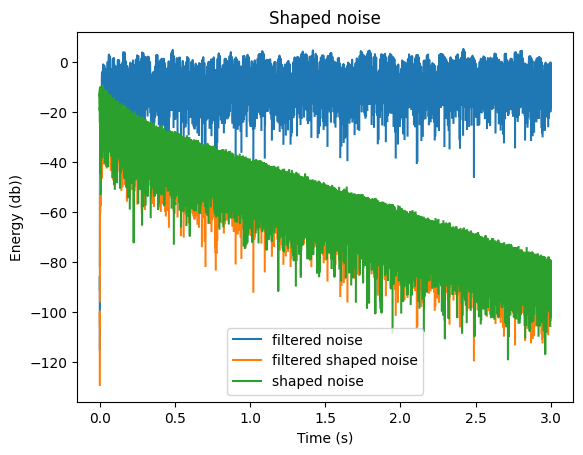

Estimated T_BDA: 
 [0.4775 1.388 ], 
A_BDA: 
 [[0.498 0.066]
 [0.305 0.201]
 [0.933 0.011]
 [0.035 0.163]
 [0.87  0.061]
 [0.756 0.071]] 
Estimated A_LS: [1.275 0.07 ] 
Reference T: [0.5 1.5], A: [2.  0.1]


In [5]:
wgn2 = np.random.randn(1,L,1)
filt_wgn = octave_filtering(wgn2[...,0], 
                            fs, 
                            BDA.get_filter_frequencies(), 
                            ir_len=L,
                            get_filter_ir=False, 
                            compensate_filter_energy=True)

shaped_noise2 = np.sum(np.einsum('ijn, ijf -> ijfn', A_e*envelope_kernel, filt_wgn), -1)
# plot energy of each channel of the shaped noise

plt.plot(time_axis, 10*np.log10(filt_wgn[0, :, 0]), label='filtered noise')
plt.plot(time_axis, 10*np.log10(shaped_noise2[0, :, 0]), label='filtered shaped noise')
plt.plot(time_axis, 10*np.log10(np.sum(A_e*envelope_kernel*wgn2, -1)[0,:]), label='shaped noise')
plt.xlabel('Time (s)')
plt.ylabel('Energy (db))')
plt.legend()
plt.title('Shaped noise')
plt.show()

edc_param, norm_vals = BDA.estimate_parameters(np.sum(shaped_noise2, -1))
T, A, N = edc_param[0], edc_param[1], edc_param[2]
print(
    f"Estimated T_BDA: \n {np.median(np.squeeze(np.round(T, 3)), axis=0)}, \nA_BDA: \n {np.squeeze(np.round(A, 3))} \n" \
    f"Estimated A_LS: {np.squeeze(np.round(A_ls, 3))} \n" \
    f"Reference T: {np.squeeze(np.round(T_s, 3))}, A: {np.squeeze(np.round(A_s, 3))}"
)



Text(0.5, 1.0, 'Energy Decay Curve')

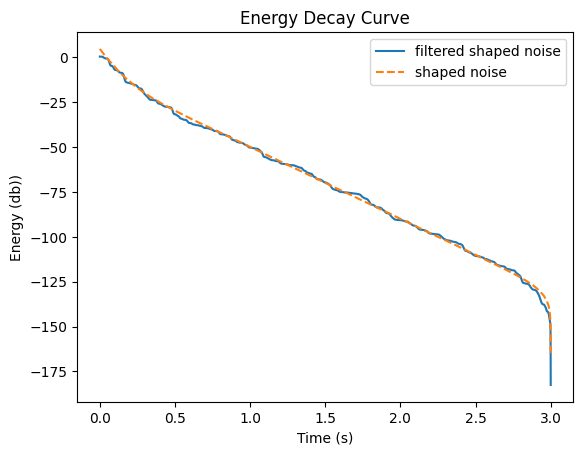

In [6]:

# plot the EDCs 
edc_shaped_noise2 = schroeder_backward_int(shaped_noise2[0, :, 0], normalize=False)
edc_target = schroeder_backward_int(np.sum(A_e*envelope_kernel*wgn2, -1)[0,:], normalize=False)
plt.plot(time_axis, 10*np.log10(edc_shaped_noise2), label='filtered shaped noise')
plt.plot(time_axis, 10*np.log10(edc_target), '--', label='shaped noise')
plt.xlabel('Time (s)')
plt.ylabel('Energy (db))')
plt.legend()
plt.title('Energy Decay Curve')